<a href="https://colab.research.google.com/github/RazyAnas/MachineLearning/blob/main/EDA_using_univariant_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
# independent analysis of single column -> each column is variants -> univariant analysis -> graphs
'''
Numerical Column?
  ├── Check: mean, median, std, skew, nulls, outliers
  └── Plot: histogram + boxplot

Categorical Column?
  ├── Check: value_counts(), null %, unique count
  └── Plot: bar chart

Target variable (classification)?
  └── Always check class balance first!
'''

In [78]:
# Data -> numerical , categorical

In [79]:
import seaborn as sns
import pandas as pd
import numpy as np

sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [80]:
df = sns.load_dataset('titanic')

In [81]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [82]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)
df = pd.read_csv('/kaggle/input/titanic-dataset/Titanic-Dataset.csv')

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


In [83]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# 1. Categorical Data

### a. Countplot

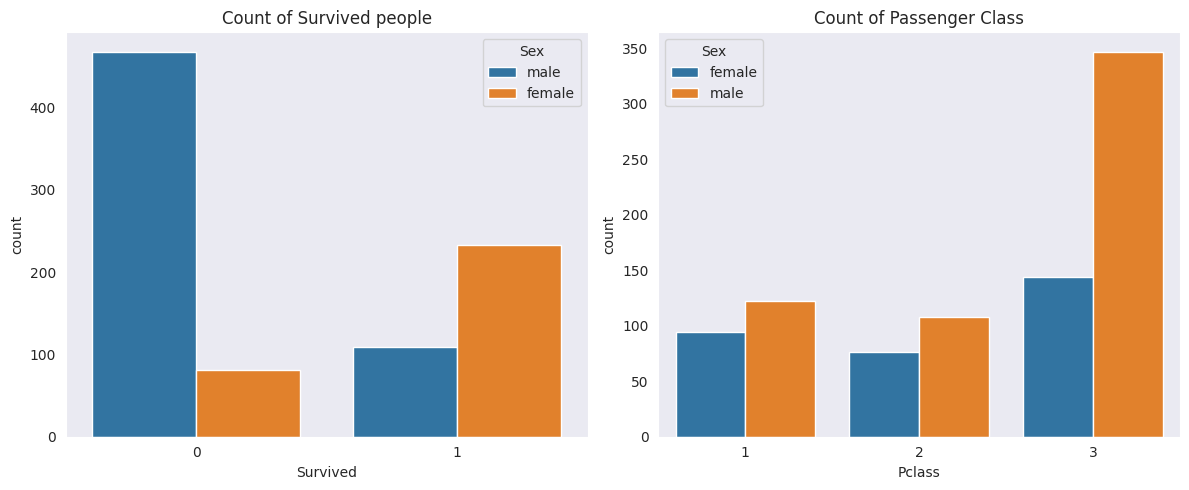

In [55]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# First countplot
sns.countplot(data=df, x='Survived', ax=axes[0], hue='Sex')
axes[0].set_title('Count of Survived people')

# Second countplot
sns.countplot(data=df, x='Pclass', ax=axes[1], hue='Sex')
axes[1].set_title('Count of Passenger Class')

# Automatically adjust spacing so plots don't overlap
plt.tight_layout()

# Display the figure
plt.show()

### b. PieChart

<Axes: ylabel='count'>

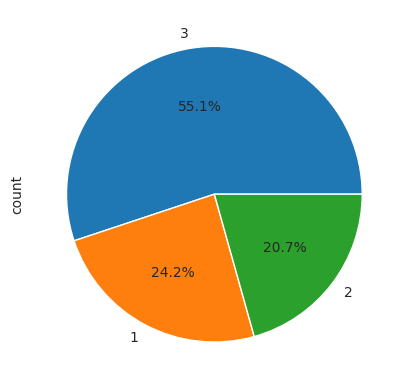

In [56]:
df['Pclass'].value_counts().plot(kind='pie', autopct='%1.1f%%')

# 2. Numerical Data

### a. Histogram

(array([ 54.,  46., 177., 169., 118.,  70.,  45.,  24.,   9.,   2.]),
 array([ 0.42 ,  8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126,
        64.084, 72.042, 80.   ]),
 <BarContainer object of 10 artists>)

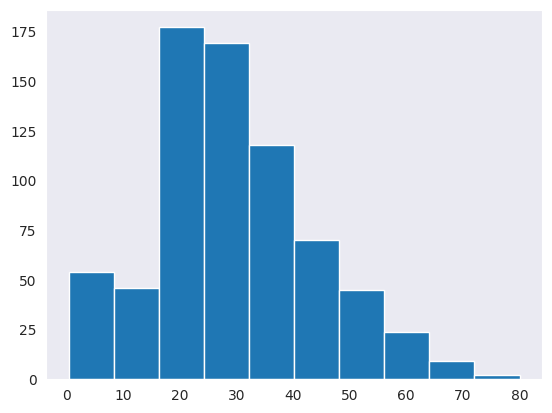

In [57]:
plt.hist(data=df, x='Age')

/tmp/ipykernel_12656/3810133007.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(


<Axes: xlabel='Age', ylabel='Density'>

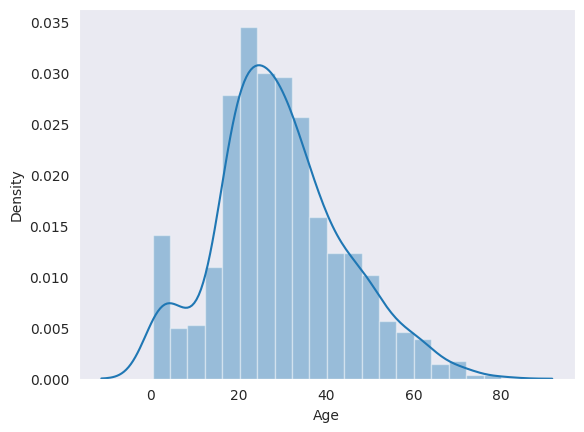

In [58]:
sns.set_style('dark')
sns.distplot(
    df['Age'],
    kde=True,            # Draw the smooth density curve
    hist=True,           # Draw histogram bars
)


In [59]:
sns.axes_style().keys()

dict_keys(['axes.facecolor', 'axes.edgecolor', 'axes.grid', 'axes.axisbelow', 'axes.labelcolor', 'figure.facecolor', 'grid.color', 'grid.linestyle', 'text.color', 'xtick.color', 'ytick.color', 'xtick.direction', 'ytick.direction', 'lines.solid_capstyle', 'patch.edgecolor', 'patch.force_edgecolor', 'image.cmap', 'font.family', 'font.sans-serif', 'xtick.bottom', 'xtick.top', 'ytick.left', 'ytick.right', 'axes.spines.left', 'axes.spines.bottom', 'axes.spines.right', 'axes.spines.top'])

### c. Box Plot

<Axes: xlabel='Fare'>

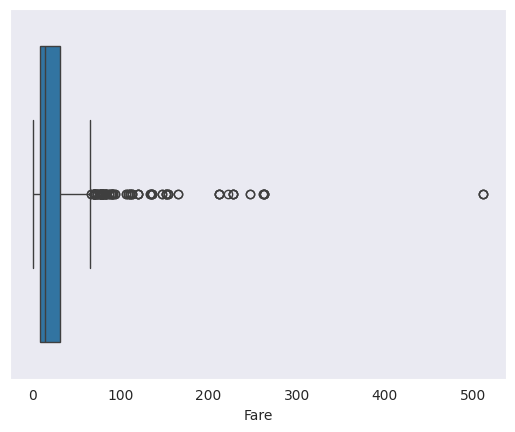

In [60]:
sns.boxplot(df['Fare'], orient='h')

In [61]:
df['Age'].min()

0.42

In [62]:
df['Age'].max()

80.0

In [63]:
df['Age'].mean()

np.float64(29.69911764705882)

In [64]:
df['Age'].skew()

np.float64(0.38910778230082704)

In [104]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")
path = path + '/dataset.csv'
spotify = pd.read_csv(path).drop(columns=["Unnamed: 0"])


Using Colab cache for faster access to the '-spotify-tracks-dataset' dataset.


In [66]:
spotify.size

2394000

In [105]:
spotify.sample(5)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
36227,19BuHpCRvqCvgpKF7DNnFq,Panta Ray,Remember That Summer,Remember That Summer,58,162762,False,0.689,0.416,0,-9.320,1,0.0324,0.5100,0.875000,0.1770,0.0971,120.027,4,french
77499,45LAadCsBXb7AMEFPajwC9,Thiago Soares,Pagode do Soares de Verão,Pra Gente Se Encontrar de Novo / É Você / Prim...,45,368822,False,0.630,0.603,2,-7.391,1,0.0468,0.7910,0.000000,0.3430,0.8790,89.725,4,pagode
94711,1sMjYDNFpNoPjNH2ifBvuA,Beowülf;INTRN,Lose A Friend,Lose A Friend,48,202605,False,0.756,0.392,6,-10.191,0,0.0446,0.2620,0.000002,0.1260,0.0658,125.022,4,sad
94013,5YOlr46EwaH34hfN6r4vXR,MC Virgins;Yun Head,Trap Anthem,Trap Anthem,68,133017,True,0.818,0.820,6,-5.531,0,0.1750,0.1060,0.000000,0.1080,0.7370,160.005,4,sad
69888,0fMxenSlOID7wRmpWXR0SR,Gersson Edinbaro,Neerae 6,Thookki Sumapeerae,19,352957,False,0.516,0.499,7,-8.395,1,0.0272,0.0755,0.000000,0.0853,0.3040,139.865,4,malay


In [106]:
spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

In [107]:
spotify.isna().sum()

,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


In [108]:
spotify.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [109]:
spotify.duplicated().sum()

np.int64(450)

In [110]:
spotify.corr(numeric_only=True)

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
popularity,1.000000,-0.007101,0.044082,0.035448,0.001056,-0.003853,0.050423,-0.013931,-0.044927,-0.025472,-0.095139,-0.005387,-0.040534,0.013205,0.031073
duration_ms,-0.007101,1.000000,-0.065263,-0.073426,0.058523,0.008114,-0.003470,-0.035556,-0.062600,-0.103788,0.124371,0.010321,-0.154479,0.024346,0.018225
explicit,0.044082,-0.065263,1.000000,0.122507,0.096955,0.004484,0.108588,-0.037212,0.307952,-0.094403,-0.103404,0.032549,-0.003381,-0.002816,0.038386
danceability,0.035448,-0.073426,0.122507,1.000000,0.134325,0.036469,0.259077,-0.069219,0.108626,-0.171533,-0.185606,-0.131617,0.477341,-0.050450,0.207218
energy,0.001056,0.058523,0.096955,0.134325,1.000000,0.048006,0.761690,-0.078362,0.142509,-0.733906,-0.181879,0.184796,0.258934,0.247851,0.187126
key,-0.003853,0.008114,0.004484,0.036469,0.048006,1.000000,0.038590,-0.135916,0.020418,-0.040937,-0.006823,-0.001600,0.034103,0.010917,0.015065
loudness,0.050423,-0.003470,0.108588,0.259077,0.761690,0.038590,1.000000,-0.041764,0.060826,-0.589803,-0.433477,0.076899,0.279848,0.212446,0.191992
mode,-0.013931,-0.035556,-0.037212,-0.069219,-0.078362,-0.135916,-0.041764,1.000000,-0.046532,0.095553,-0.049955,0.014012,0.021953,0.000566,-0.024092
speechiness,-0.044927,-0.062600,0.307952,0.108626,0.142509,0.020418,0.060826,-0.046532,1.000000,-0.002186,-0.089616,0.205219,0.036635,0.017273,-0.000011
acousticness,-0.025472,-0.103788,-0.094403,-0.171533,-0.733906,-0.040937,-0.589803,0.095553,-0.002186,1.000000,0.104027,-0.020700,-0.107070,-0.208224,-0.176138


In [111]:
spotify.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [112]:
spotify.skew(numeric_only=True)

,0
popularity,0.046403
duration_ms,11.195181
explicit,2.964731
danceability,-0.399497
energy,-0.597001
key,-0.008500
loudness,-2.006542
mode,-0.572300
speechiness,4.647516
acousticness,0.727295


In [113]:
# Univariant analysis -> each column

<Axes: xlabel='popularity'>

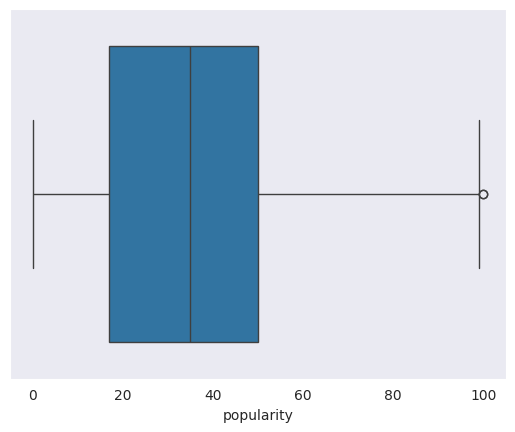

In [114]:
# Numeric
sns.boxplot(data=spotify, x='popularity')

In [76]:
spotify.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [92]:
spotify = spotify[spotify['popularity'] != 0]

/tmp/ipykernel_12656/1396503747.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(spotify['popularity'], kde=True, hist=True)


<Axes: xlabel='popularity', ylabel='Density'>

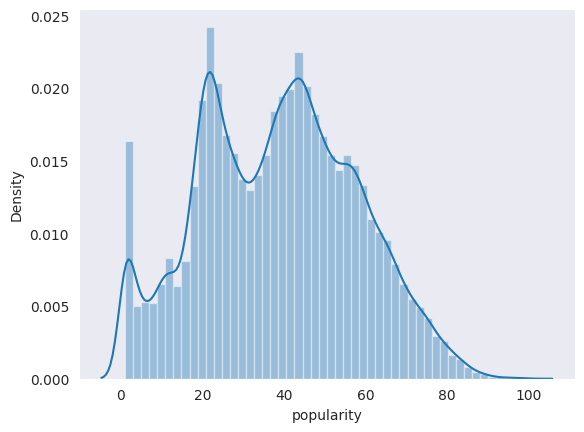

In [96]:
sns.distplot(spotify['popularity'], kde=True, hist=True)

In [76]:
# independent analysis of single column -> each column is variants -> univariant analysis -> graphs
'''
Numerical Column?
  ├── Check: mean, median, std, skew, nulls, outliers
  └── Plot: histogram + boxplot

Categorical Column?
  ├── Check: value_counts(), null %, unique count
  └── Plot: bar chart

Target variable (classification)?
  └── Always check class balance first!
'''

In [118]:
spotify.value_counts('track_genre').size

114

In [146]:
spotify.groupby('artists')['popularity'].mean().sort_values(ascending=False).head(10)

,popularity
artists,
Sam Smith;Kim Petras,100.0
Bizarrap;Quevedo,99.0
Manuel Turizo,98.0
Bad Bunny;Chencho Corleone,97.0
Bad Bunny;Bomba Estéreo,94.5
Joji,94.0
Beyoncé,93.0
Rema;Selena Gomez,92.0
Harry Styles,92.0


In [137]:
spotify.value_counts('artists').sort_values(ascending=False).head(10)

,count
artists,
The Beatles,279
George Jones,271
Stevie Wonder,236
Linkin Park,224
Ella Fitzgerald,222
Prateek Kuhad,217
Feid,202
Chuck Berry,190
Håkan Hellström,183


<Axes: ylabel='count'>

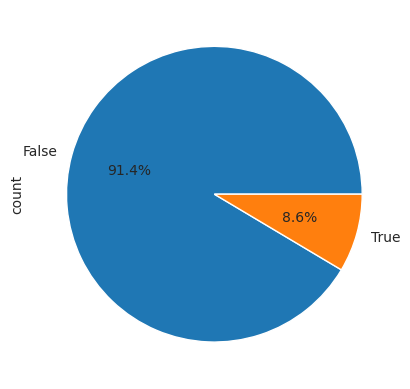

In [149]:
spotify['explicit'].value_counts().plot(kind='pie', autopct='%1.1f%%')

<Axes: xlabel='loudness'>

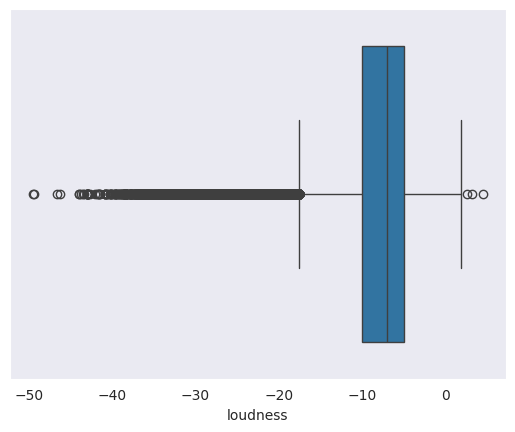

In [150]:
sns.boxplot(spotify, x='loudness')

<Axes: xlabel='speechiness'>

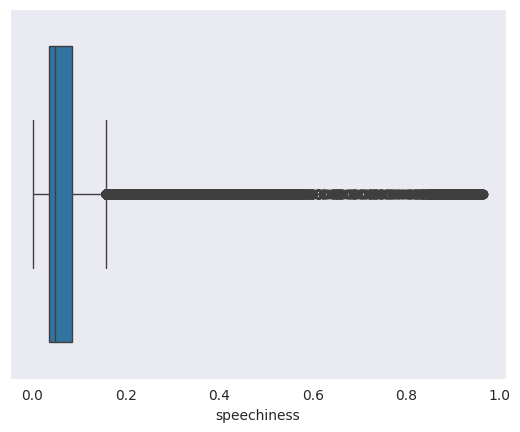

In [151]:
sns.boxplot(spotify, x='speechiness')